## Tomatoes Day 1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [3]:
prices_raw = pd.read_csv("prices_round_0_day_-1.csv", sep = ";", index_col = "timestamp")
prices_raw

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
0,-1,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
100,-1,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
100,-1,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
200,-1,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999700,-1,EMERALDS,9992,12,9990,26,NaN,NaN,10008,12,10010,26,NaN,NaN,10000.0,0.0
999800,-1,EMERALDS,9992,13,9990,20,NaN,NaN,10008,13,10010,20,NaN,NaN,10000.0,0.0
999800,-1,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0


In [4]:
t = prices_raw[prices_raw["product"] != "EMERALDS"]
t

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
100,-1,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
200,-1,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0
300,-1,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0
400,-1,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999500,-1,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
999600,-1,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
999700,-1,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0


In [2]:
start = 0
window = 1000000
range = [start, start + window]

t.mid_price.plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
t.bid_price_1.plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
t.ask_price_1.plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
plt.legend(fontsize = 13)
plt.show()

NameError: name 't' is not defined

C:\Users\spenc\AppData\Local\Temp\ipykernel_22976\3869055471.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 13)


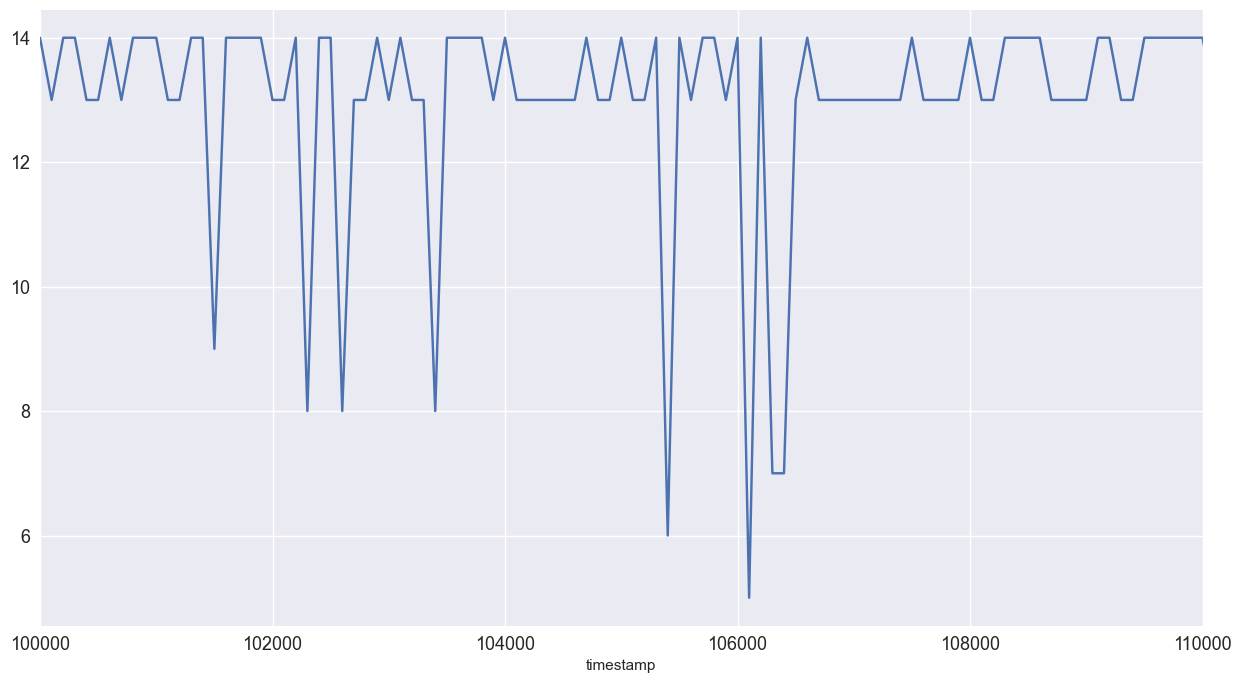

In [37]:
spread = t.ask_price_1 - t.bid_price_1

spread.plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
plt.legend(fontsize = 13)
plt.show()

In [6]:
x_model = np.arange(0, 1000000, 100)

In [7]:
x_model.shape

(10000,)

In [8]:
ones = np.ones((len(x_model)))
ones.shape

(10000,)

In [9]:
X = np.vstack([ones, x_model]).T
X.shape

(10000, 2)

In [10]:
Y = t.mid_price.values.reshape((len(t.mid_price), 1))

In [11]:
X.shape, Y.shape

((10000, 2), (10000, 1))

In [12]:
beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(Y))
beta

array([[ 4.99922385e+03],
       [-4.33165332e-05]])

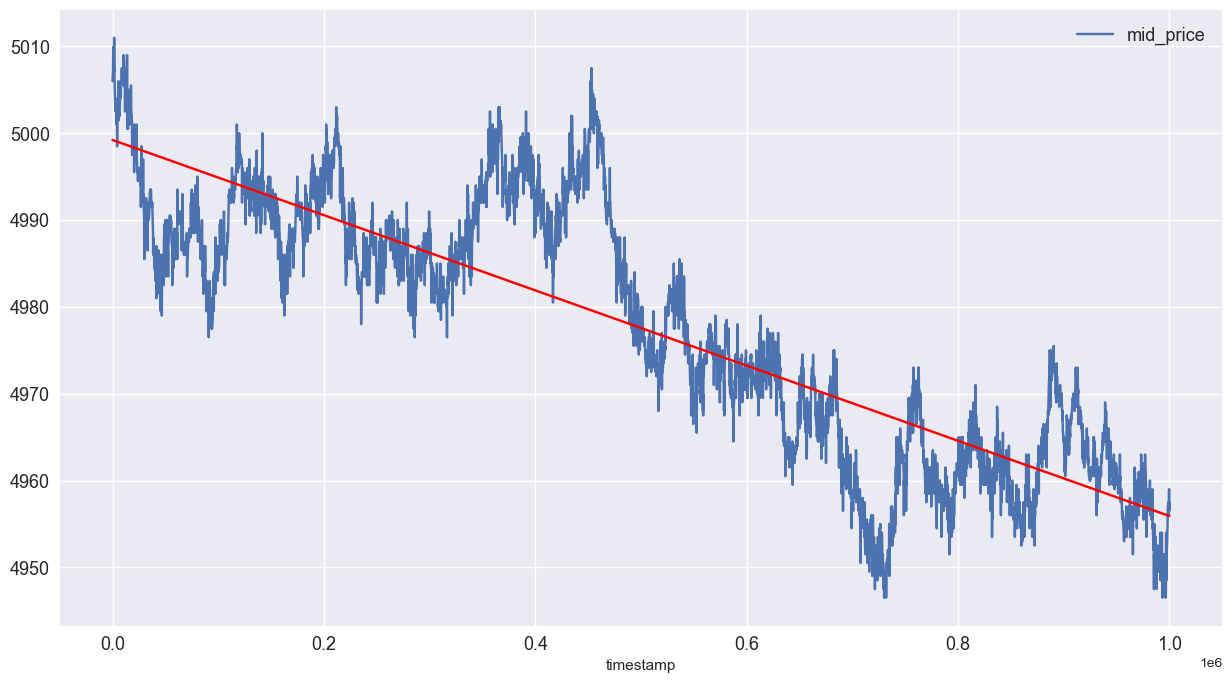

In [15]:
t.mid_price.plot(figsize = (15, 8), fontsize = 13)
x_model = np.arange(0, 1000000, 100)
y_model = t.index * beta[1] + beta[0]
plt.plot(x_model, y_model, 'r-')
plt.legend(fontsize = 13)
plt.show()

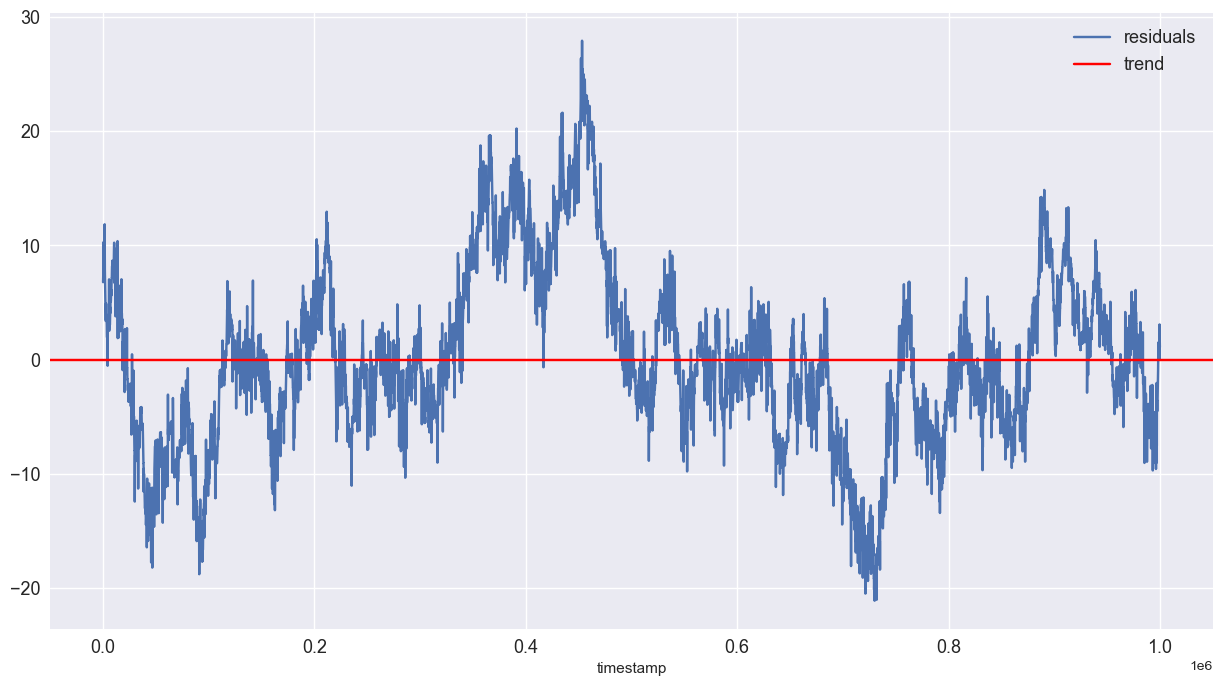

In [14]:
residuals = t.mid_price - y_model
residuals.plot(figsize=(15, 8), fontsize=13, label="residuals")
plt.axhline(0, color='r', linestyle='-', label = "trend")
plt.legend(fontsize = 13)
plt.show()

In [15]:
window = 50
sma = t.mid_price.rolling(window).mean().to_frame()
sma.rename(columns={"mid_price": "rolling_mean"}, inplace=True)
sma["rolling_std"] = t.mid_price.rolling(window).std()
sma["raw"] = t.mid_price
sma

,rolling_mean,rolling_std,raw
timestamp,,,
0,NaN,NaN,5006.0
100,NaN,NaN,5006.5
200,NaN,NaN,5006.5
300,NaN,NaN,5007.0
400,NaN,NaN,5007.0
...,...,...,...
999500,4952.63,3.140925,4959.0
999600,4952.79,3.257785,4959.0
999700,4952.90,3.288818,4956.5


<Axes: xlabel='timestamp'>

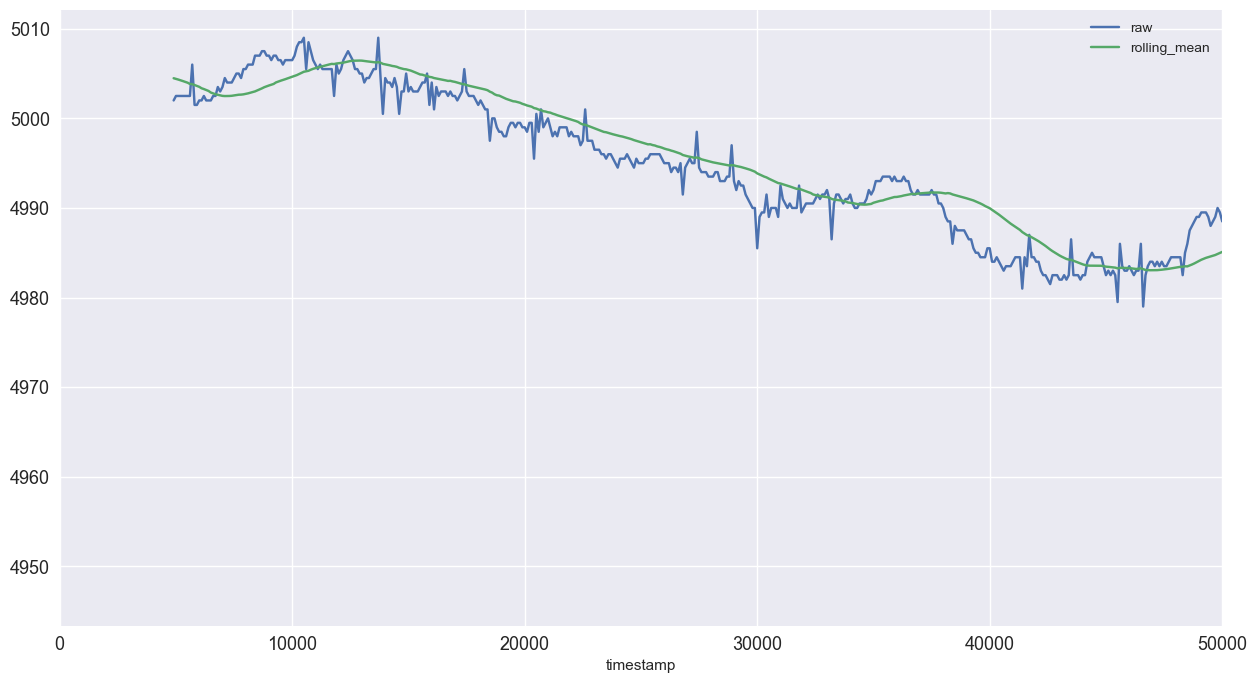

In [31]:
range = [0,50000]
sma = sma.dropna()
sma[["raw", "rolling_mean"]].plot(figsize=(15, 8), fontsize=13, xlim=(range[0], range[1]))

In [17]:
sma["z_score"] = (sma.raw - sma.rolling_mean) / sma.rolling_std
sma["detrend"] = residuals

C:\Users\spenc\AppData\Local\Temp\ipykernel_28008\3940523836.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sma["z_score"] = (sma.raw - sma.rolling_mean) / sma.rolling_std
C:\Users\spenc\AppData\Local\Temp\ipykernel_28008\3940523836.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sma["detrend"] = residuals


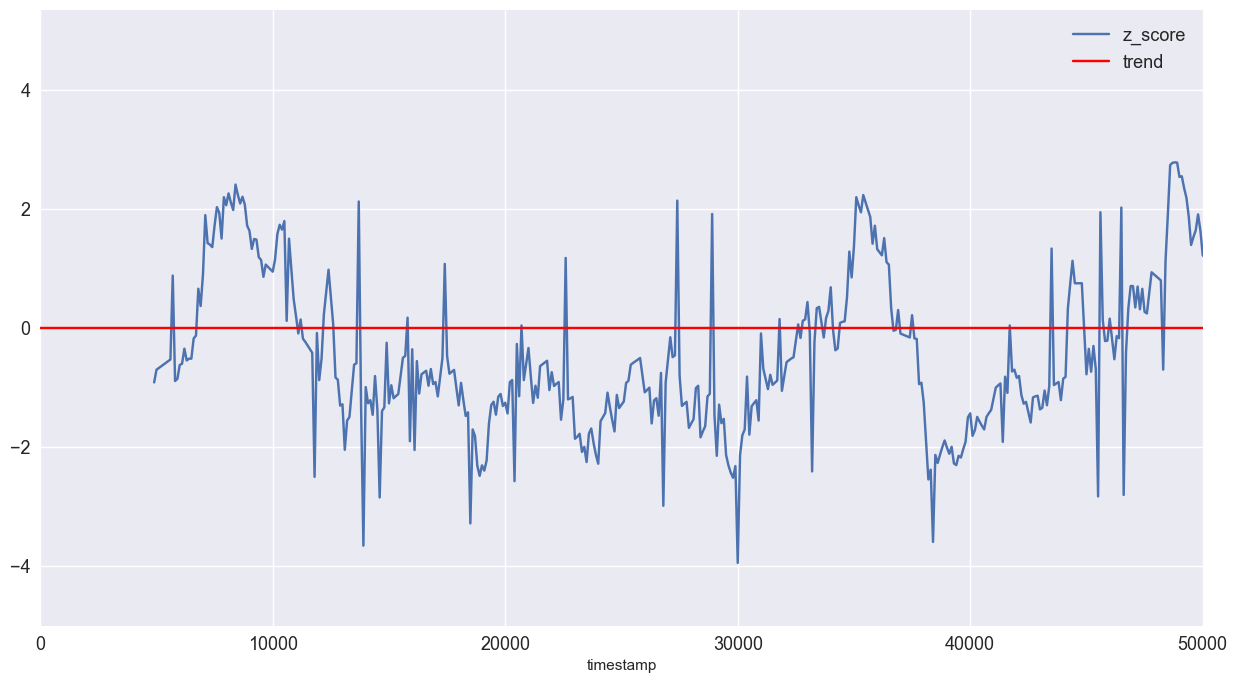

In [32]:
sma["z_score"].plot(figsize=(15, 8), fontsize=13, xlim=(range[0], range[1]))
plt.axhline(0, color='r', linestyle='-', label = "trend")
plt.legend(fontsize = 13)
plt.show()

In [71]:
sma["z_score"].max()

4.044296500167932